In [1]:
# !apt-get update
# !apt-get install -y python-opengl ffmpeg
# !apt-get install --upgrade cmake
# !apt install swig xvfb
!pip install -U -qq matplotlib gymnasium[box2d] 

In [2]:
import gymnasium as gym
from gymnasium.wrappers import RecordVideo
from torch.optim import AdamW
from torch.nn import MSELoss
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torch
import os
import re
import numpy as np
from dataclasses import dataclass   
import random
from collections import deque
from typing import List
from pathlib import Path
import matplotlib.pyplot as plt


environment_name = "LunarLander-v3"
env = gym.make(environment_name, render_mode="rgb_array")

# create a recording copy that will save the simulation to a video file on every run
trigger = lambda t: True # small function that tells the recording env when to record, in our case always
recording_env = RecordVideo(env, "./checkpoint_videos", episode_trigger=trigger)

In [3]:


def get_latest_episode_video_file(directory):
    # Regular expression to match the file format and capture the episode number
    pattern = re.compile(r"rl-video-episode-(\d+)\.mp4")
    latest_file = None
    highest_episode = -1

    # Search through files in the directory
    for filename in os.listdir(directory):
        match = pattern.match(filename)
        if match:
            episode_number = int(match.group(1))  # Extract episode number
            # Check if this episode number is the highest found
            if episode_number > highest_episode:
                highest_episode = episode_number
                latest_file = os.path.join(directory, filename)  # Store the full path

    return latest_file

latest_file = get_latest_episode_video_file("./checkpoint_videos")
print(latest_file) # outputs: ./checkpoint_videos/rl-video-episode-4.mp4

None


In [4]:

class AgentNetwork(nn.Module):
    def __init__(self, n_actions, input_shape):
        super(AgentNetwork, self).__init__()
        self.n_actions = n_actions
        self.input_shape = input_shape
        self.fc1 = nn.Linear(input_shape, 64)
        self.fc2 = nn.Linear(64, 64)
        self.fc3 = nn.Linear(64, n_actions)

    def forward(self, x):
        x = self.fc1(x)
        x = F.relu(x)
        x = self.fc2(x)
        x = F.relu(x)
        x = self.fc3(x)
        return x
    
    def get_action(self, x):
        x = self.forward(x)
        return torch.argmax(x)

In [5]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
agent_network = AgentNetwork((env.action_space.n), env.observation_space.shape[0]).to(device)

In [6]:

learning_rate = .0001
optimizer = AdamW(agent_network.parameters(), weight_decay=0.01, lr=learning_rate)
loss_fn = MSELoss()

In [7]:

# data class that stores the sample data
@dataclass
class ReplayBufferSample:
    state: any
    action: any
    reward: float
    new_state: any
    was_terminal: bool


# replay buffer for holding and retrieving samples
class ReplayBuffer:
    def __init__(self, capacity: int):
        self.capacity = capacity
        self.buffer = deque(maxlen=capacity) 

    def add_new_sample(self, state, action, reward, new_state, was_terminal):
        sample = ReplayBufferSample(state, action, reward, new_state, was_terminal)
        self.buffer.append(sample)

    def get_pytorch_training_samples(self, batch_size):
        samples = random.sample(self.buffer, batch_size)
        states = torch.tensor(
            np.stack([s.state for s in samples]),
            dtype=torch.float32,
            device=device
        )

        actions = torch.tensor(
            [s.action for s in samples],
            device=device
        )

        rewards = torch.tensor(
            [s.reward for s in samples],
            dtype=torch.float32,
            device=device
        )

        new_states = torch.tensor(
            np.stack([s.new_state for s in samples]),
            dtype=torch.float32,
            device=device
        )

        was_terminals = torch.tensor(
            [s.was_terminal for s in samples],
            device=device
        )
        return states, actions, rewards, new_states, was_terminals

    def __len__(self):
        return len(self.buffer) 

In [ ]:

class AgentDeepQTrainer:
    def __init__(self, env, recording_env, agent_network, loss_fn, optimizer, nn_type, eps_min=0.01, eps_dec=5e-6, replay_buffer_size=100000, learning_batch_size=64, replace_target_count=500, discount=0.99, print_status_steps=100):
        self.env = env
        self.recording_env = recording_env
        self.nn_type = nn_type

        self.agent_network = agent_network
        self.target_network = AgentNetwork(self.agent_network.n_actions, self.agent_network.input_shape).to(device)
        # self.target_network.load_state_dict(self.agent_network.state_dict())

        self.loss_fn = loss_fn
        self.optimizer = optimizer
        self.epsilon = 1
        self.epsilon_min = eps_min
        self.epsilon_decrement=eps_dec

        self.replace_target_count = replace_target_count
        self.replay_buffer = ReplayBuffer(replay_buffer_size)
        self.learn_step_counter = 0
        self.discount = discount
        self.learning_batch_size = learning_batch_size
        self.print_status_steps=print_status_steps

        self.training_rewards = []

    
    def choose_action_with_epsilon(self, observation, epsilon):

        if np.random.random() > epsilon:
            with torch.no_grad():
                
                observation = torch.tensor(np.array(observation), dtype=torch.float).to(device)
                return self.agent_network.get_action(observation).item()
        
        return self.env.action_space.sample()        

    def learn_step(self):
        if len(self.replay_buffer) <= self.learning_batch_size:
            return
        
        if self.learn_step_counter % self.replace_target_count == 0: 
            self.target_network.load_state_dict(self.agent_network.state_dict())

        self.optimizer.zero_grad()
        
        samples = self.replay_buffer.get_pytorch_training_samples(self.learning_batch_size)
        states, actions, rewards, new_states, was_terminals = samples

        indices = np.arange(self.learning_batch_size)
        q_pred = self.agent_network.forward(states)[indices, actions]
        if self.nn_type == "dqn":
            q_next = self.target_network.forward(new_states).max(dim=1)[0]
        else:
            # 1. Use ONLINE network to choose best actions
            q_eval_next = self.agent_network.forward(new_states)
            max_actions = torch.argmax(q_eval_next, dim=1)

            # 2. Use TARGET network to evaluate those actions
            q_next_target = self.target_network.forward(new_states)

            q_next = q_next_target[indices, max_actions]
            
        q_next[was_terminals] = 0.0 # in case we have a terminal state, next state value is always 0!

        q_label = rewards + self.discount * q_next

        # we calculate the loss
        loss = self.loss_fn(q_label, q_pred).to(device)
        loss.backward() 
        self.optimizer.step()

        self.learn_step_counter += 1
        self.epsilon = max(self.epsilon - self.epsilon_decrement, self.epsilon_min)


    
    def run_eval_episode(self, record=False):
        # reset the recording_env which should have a recording wrapper
        env = self.recording_env if record else self.env
        state = env.reset()[0]
        done = False
        truncated = False
        eval_reward = 0
        step = 0
        with torch.no_grad():
            while not done and not truncated:
                step += 1
                if record:
                    env.render()
                
                state = torch.tensor([state], dtype=torch.float).to(device)
                # get the agent action for the state, 
                action = self.agent_network.get_action(state).item()

                # perform the action and add reward
                state, reward, done, truncated, _ = env.step(action)
                eval_reward += reward
        env.close()
        return eval_reward

    def run_train_episode(self):
        state = self.env.reset()[0]
        done = False
        truncated = False
        total_reward = 0
        while not done and not truncated:
            action = self.choose_action_with_epsilon(state, self.epsilon)

            new_state, reward, done, truncated, _ = self.env.step(action)

            self.replay_buffer.add_new_sample(state, action, reward, new_state, done)

            state = new_state
            total_reward += reward

            self.learn_step()

        return total_reward

    def save_model(self, file_path):
        torch.save(self.agent_network.state_dict(), file_path)


    def train(self, num_episodes):
        self.training_rewards = []
        for episode in range(num_episodes+1):
            training_reward = self.run_train_episode()
            self.training_rewards.append(training_reward)
            if episode %  100 == 0:
                print(f"Episode {episode}: {training_reward:.2f}")
            

In [9]:
trainer_dqn = AgentDeepQTrainer(env, recording_env, agent_network, loss_fn, optimizer, "dqn")
trainer_ddqn = AgentDeepQTrainer(env, recording_env, agent_network, loss_fn, optimizer, "ddqn")

In [10]:
trainer_dqn.train(1500)
trainer_dqn.save_model("model_dqn.pth")

Episode 0: -213.38
Episode 100: -226.94
Episode 200: -120.19
Episode 300: -132.42
Episode 400: -138.59
Episode 500: -191.64
Episode 600: -89.37
Episode 700: -32.52
Episode 800: -78.64
Episode 900: -17.38
Episode 1000: -3.67
Episode 1100: -95.93
Episode 1200: -3.91
Episode 1300: 222.16
Episode 1400: 185.78
Episode 1500: 235.47


In [12]:
trainer_ddqn.train(1500)
trainer_ddqn.save_model("model_ddqn.pth")

Episode 0: 21.19
Episode 100: 186.55
Episode 200: 248.46
Episode 300: 176.46
Episode 400: 194.89
Episode 500: 161.94
Episode 600: 205.08
Episode 700: 142.03
Episode 800: 198.49
Episode 900: 254.13
Episode 1000: 204.84
Episode 1100: 230.02
Episode 1200: 246.28
Episode 1300: 241.87
Episode 1400: 263.36
Episode 1500: 228.69


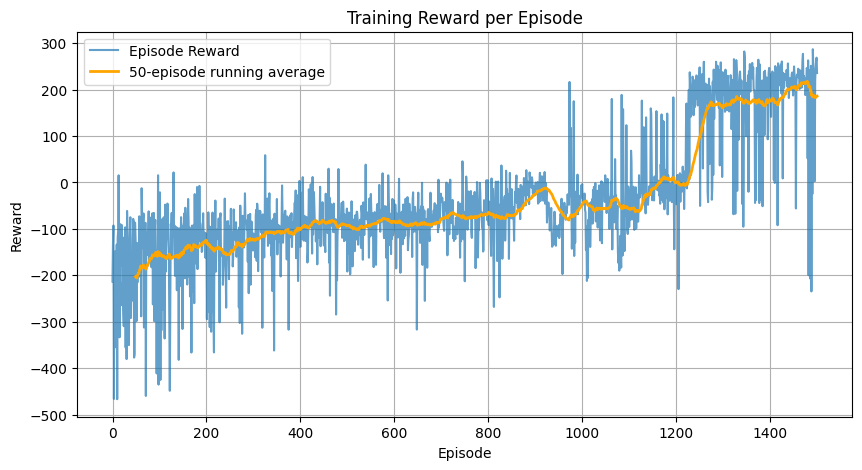

In [15]:
rewards_total = trainer_dqn.training_rewards
window_size = 50

if len(rewards_total) >= window_size:
    running_avg = np.convolve(rewards_total, np.ones(window_size) / window_size, mode='valid')
    avg_x = np.arange(window_size - 1, len(rewards_total))
else:
    running_avg = np.array([])
    avg_x = np.array([])

plt.figure(figsize=(10, 5))
plt.plot(rewards_total, label='Episode Reward', alpha=0.7)
if len(running_avg):
    plt.plot(avg_x, running_avg, label=f'{window_size}-episode running average', color='orange', linewidth=2)
plt.xlabel('Episode')
plt.ylabel('Reward')
plt.title('Training Reward per Episode')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
trainers = []
agent_network = torch.load("model_dqn.pth", map_location=device, weights_only=False)
agent_network.eval()
trainers.append(AgentDeepQTrainer(env, recording_env, agent_network, loss_fn, optimizer, "ddqn"))

# agent_network = torch.load("model_ddqn.pth", map_location=device, weights_only=False)
# agent_network.eval()
# trainers.append(AgentDeepQTrainer(env, recording_env, agent_network, loss_fn, optimizer, "dqn"))

/tmp/ipykernel_963/3422301267.py:126: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /pytorch/torch/csrc/utils/tensor_new.cpp:253.)
  state = torch.tensor([state], dtype=torch.float).to(device)


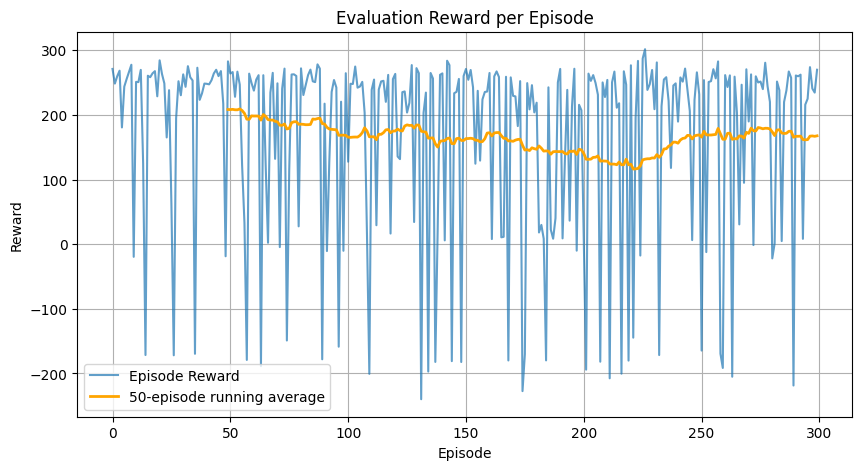

In [ ]:
def evaluate(trainer, eval_episodes = 300):

    eval_rewards = []
    for i in range(eval_episodes):
        eval_reward = trainer.run_eval_episode()
        eval_rewards.append(eval_reward)

    rewards_total = eval_rewards
    window_size = 50

    if len(rewards_total) >= window_size:
        running_avg = np.convolve(rewards_total, np.ones(window_size) / window_size, mode='valid')
        avg_x = np.arange(window_size - 1, len(rewards_total))
    else:
        running_avg = np.array([])
        avg_x = np.array([])

    plt.figure(figsize=(10, 5))
    plt.plot(rewards_total, label='Episode Reward', alpha=0.7)
    if len(running_avg):
        plt.plot(avg_x, running_avg, label=f'{window_size}-episode running average', color='orange', linewidth=2)
    plt.xlabel('Episode')
    plt.ylabel('Reward')
    plt.title('Evaluation Reward per Episode')
    plt.legend()
    plt.grid(True)
    plt.show()

for trainer in trainers:
    evaluate(trainer)

In [ ]:

eval_reward = trainers[0].run_eval_episode(True)


In [ ]:

# helper for q values
def get_q_values(state, agent_network):
    state_tensor = torch.tensor([state], dtype=torch.float32).to(device)
    with torch.no_grad():
        q = agent_network(state_tensor).cpu().numpy()[0]
    return q

def visualize(agent_network):
    angles = np.linspace(-1.5, 1.5, 100)
    angular_vels = np.linspace(-4.0, 4.0, 100)

    heatmap_av = np.zeros((len(angular_vels), len(angles)))
    policy_av = np.zeros((len(angular_vels), len(angles)))

    for i, angle in enumerate(angles):
        for j, ang_vel in enumerate(angular_vels):

            state = np.array([
                0.0, 1.0,
                0.0, 0.0,
                angle, ang_vel,
                0.0, 0.0
            ], dtype=np.float32)

            q = get_q_values(state, agent_network)

            heatmap_av[j, i] = np.max(q)
            policy_av[j, i] = np.argmax(q)

    heatmap_av = (heatmap_av - heatmap_av.min()) / (heatmap_av.max() - heatmap_av.min())


    plt.figure(figsize=(10, 8))
    plt.imshow(
        heatmap_av,
        origin='lower',
        extent=[angles.min(), angles.max(), angular_vels.min(), angular_vels.max()],
        aspect='auto',
        cmap='viridis'
    )
    plt.colorbar(label='Normalized max Q(s,a)')
    plt.xlabel("Angle")
    plt.ylabel("Angular Velocity")
    plt.title("Q-Value Heatmap (Angle vs Angular Velocity)")
    plt.show()

    x_vals = np.linspace(-1.5, 1.5, 100)
    y_vals = np.linspace(0.0, 1.5, 100)

    heatmap_xy = np.zeros((len(y_vals), len(x_vals)))

    for i, x in enumerate(x_vals):
        for j, y in enumerate(y_vals):

            state = np.array([
                x, y,
                0.0, 0.0,
                0.0, 0.0,
                0.0, 0.0
            ], dtype=np.float32)

            q = get_q_values(state, agent_network)
            heatmap_xy[j, i] = np.max(q)

    heatmap_xy = (heatmap_xy - heatmap_xy.min()) / (heatmap_xy.max() - heatmap_xy.min())


    plt.figure(figsize=(10, 8))
    plt.imshow(
        heatmap_xy,
        origin='lower',
        extent=[x_vals.min(), x_vals.max(), y_vals.min(), y_vals.max()],
        aspect='auto',
        cmap='viridis'
    )
    plt.colorbar(label='Normalized max Q(s,a)')
    plt.xlabel("X Position")
    plt.ylabel("Y Position")
    plt.title("Q-Value Heatmap (Position Space)")
    plt.show()

    vx_vals = np.linspace(-2.0, 2.0, 100)
    vy_vals = np.linspace(-2.0, 2.0, 100)

    heatmap_v = np.zeros((len(vy_vals), len(vx_vals)))

    for i, vx in enumerate(vx_vals):
        for j, vy in enumerate(vy_vals):

            state = np.array([
                0.0, 0.0,
                vx, vy,
                0.0, 0.0,
                0.0, 0.0
            ], dtype=np.float32)

            q = get_q_values(state, agent_network)
            heatmap_v[j, i] = np.max(q)

    heatmap_v = (heatmap_v - heatmap_v.min()) / (heatmap_v.max() - heatmap_v.min())


    plt.figure(figsize=(10, 8))
    plt.imshow(
        heatmap_v,
        origin='lower',
        extent=[vx_vals.min(), vx_vals.max(), vy_vals.min(), vy_vals.max()],
        aspect='auto',
        cmap='viridis'
    )
    plt.colorbar(label='Normalized max Q(s,a)')
    plt.xlabel("X Velocity")
    plt.ylabel("Y Velocity")
    plt.title("Q-Value Heatmap (Velocity Space)")
    plt.show()

    plt.figure(figsize=(10, 8))
    plt.imshow(
        policy_av,
        origin='lower',
        extent=[angles.min(), angles.max(), angular_vels.min(), angular_vels.max()],
        aspect='auto',
        cmap='tab10'
    )

    cbar = plt.colorbar()
    cbar.set_ticks([0, 1, 2, 3])
    cbar.set_ticklabels([
        "No-op",
        "Left Engine",
        "Main Engine",
        "Right Engine"
    ])

    plt.xlabel("Angle")
    plt.ylabel("Angular Velocity")
    plt.title("Policy Map (Angle vs Angular Velocity)")
    plt.show()

    x_vals = np.linspace(-3.5, 3.5, 100)
    y_vals = np.linspace(0.0, 1.5, 100)

    policy_xy = np.zeros((len(y_vals), len(x_vals)))

    for i, x in enumerate(x_vals):
        for j, y in enumerate(y_vals):

            state = np.array([
                x, y,
                0.0, 0.0,      # vx, vy fixed
                0.0, 0.0,      # angle, angular velocity fixed
                0.0, 0.0       # leg contacts fixed
            ], dtype=np.float32)

            state_tensor = torch.tensor([state], dtype=torch.float32).to(device)

            with torch.no_grad():
                q_values = agent_network(state_tensor).cpu().numpy()[0]

            policy_xy[j, i] = np.argmax(q_values)


    # plot
    plt.figure(figsize=(10, 8))

    plt.imshow(
        policy_xy,
        origin='lower',
        extent=[x_vals.min(), x_vals.max(), y_vals.min(), y_vals.max()],
        aspect='auto',
        cmap='tab10'
    )

    cbar = plt.colorbar()
    cbar.set_ticks([0, 1, 2, 3])
    cbar.set_ticklabels([
        "No-op",
        "Left Engine",
        "Main Engine",
        "Right Engine"
    ])

    plt.xlabel("X Position")
    plt.ylabel("Y Position")
    plt.title("Policy Map (X vs Y Position)")
    plt.show()

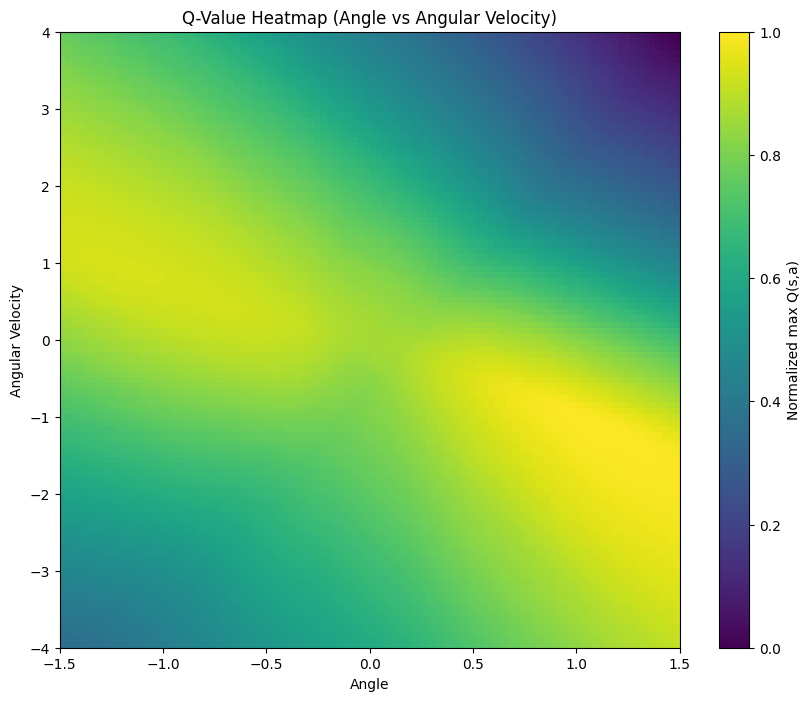

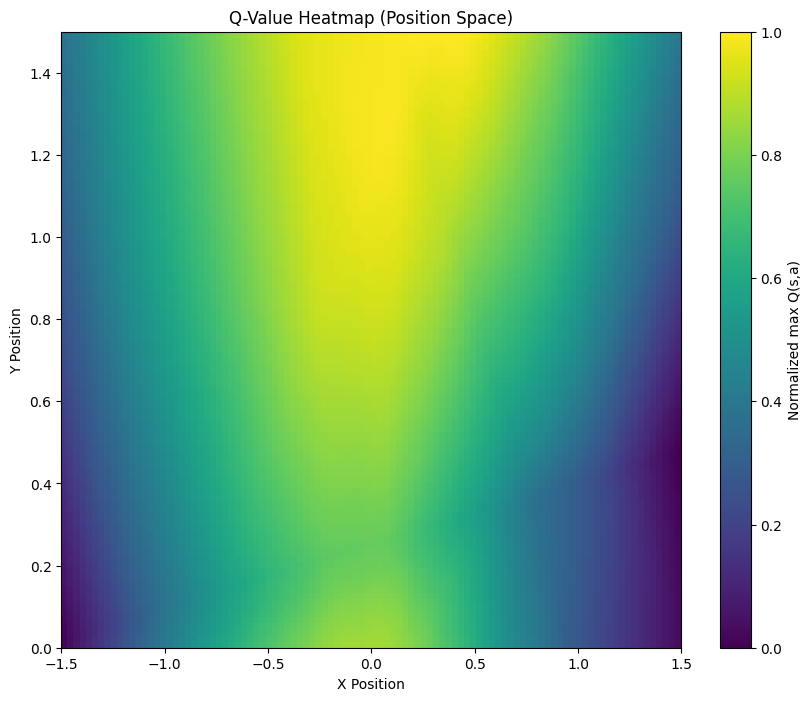

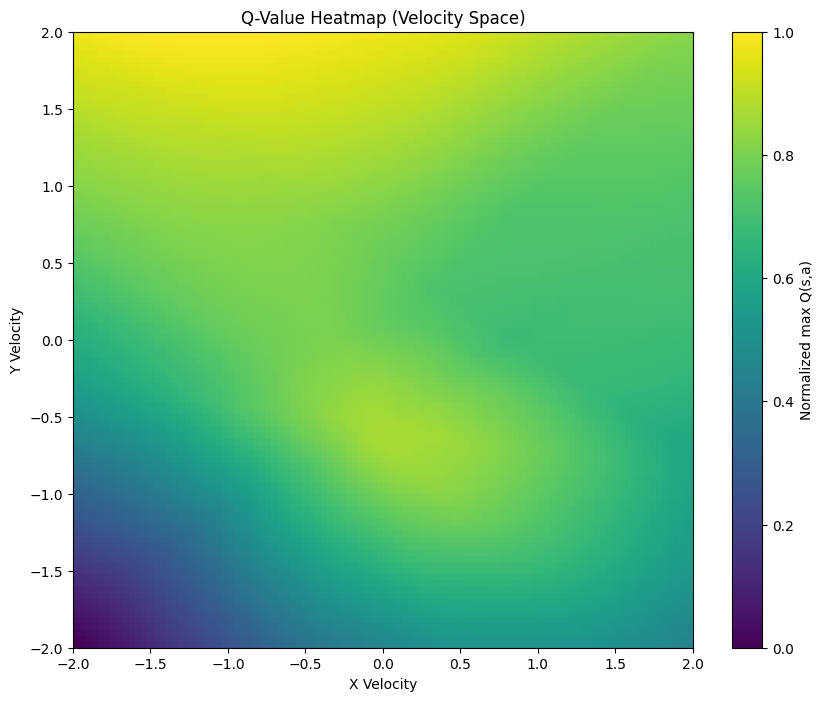

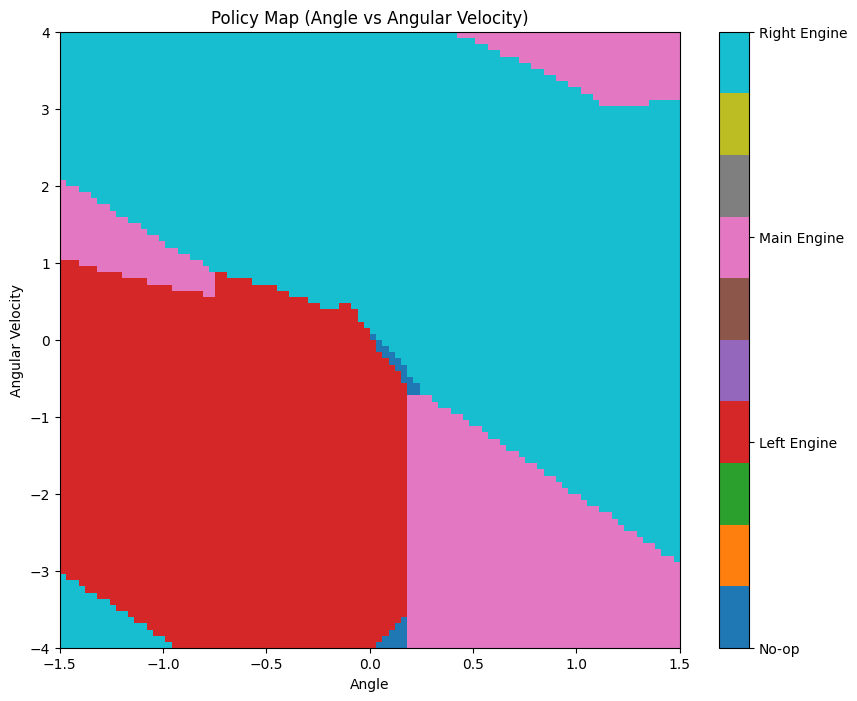

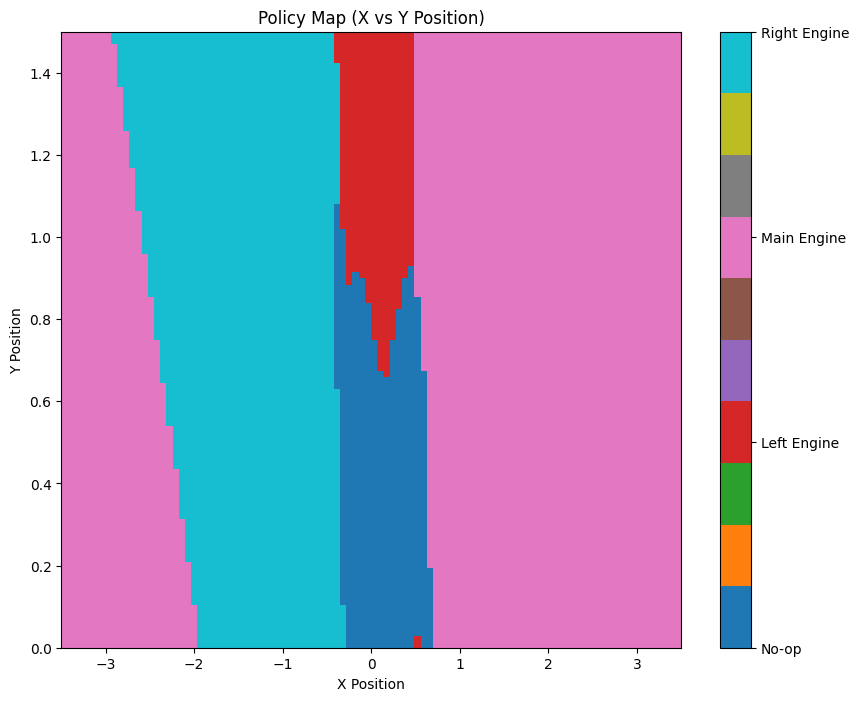

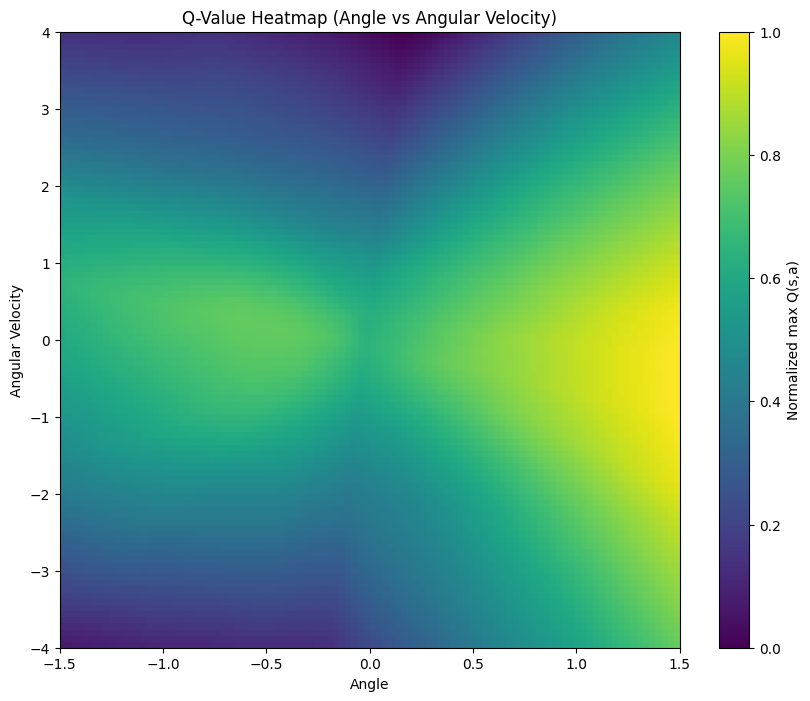

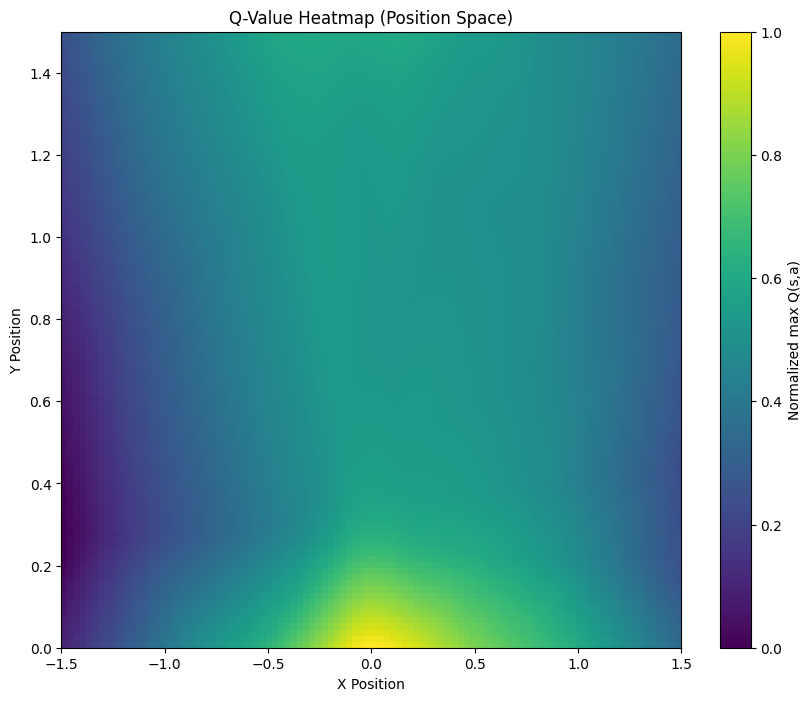

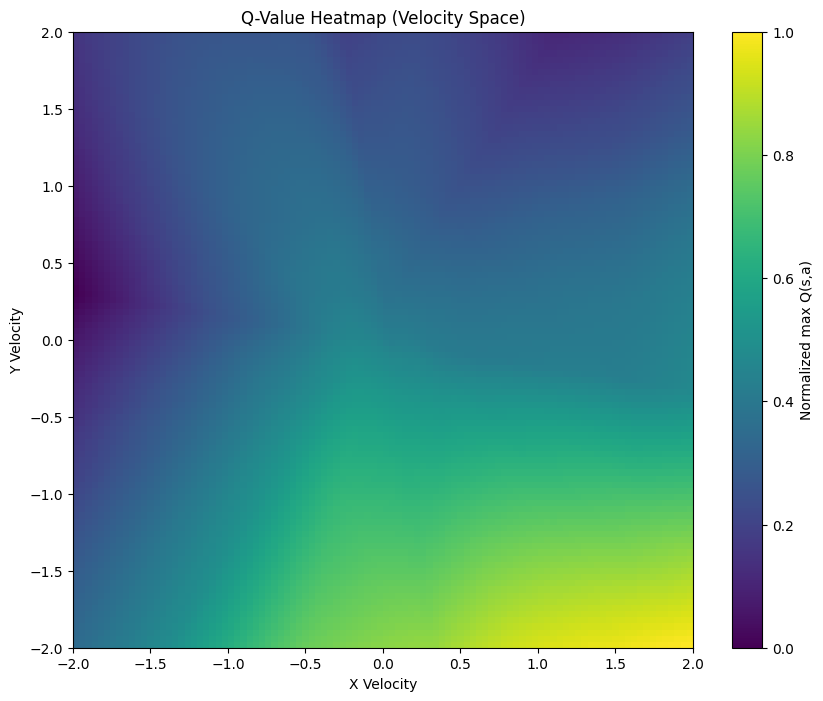

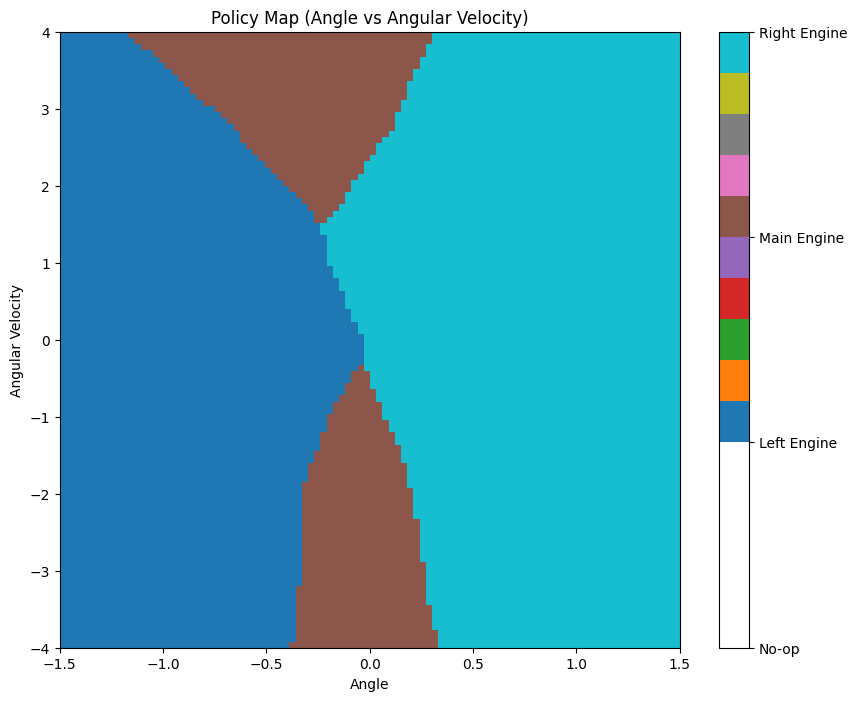

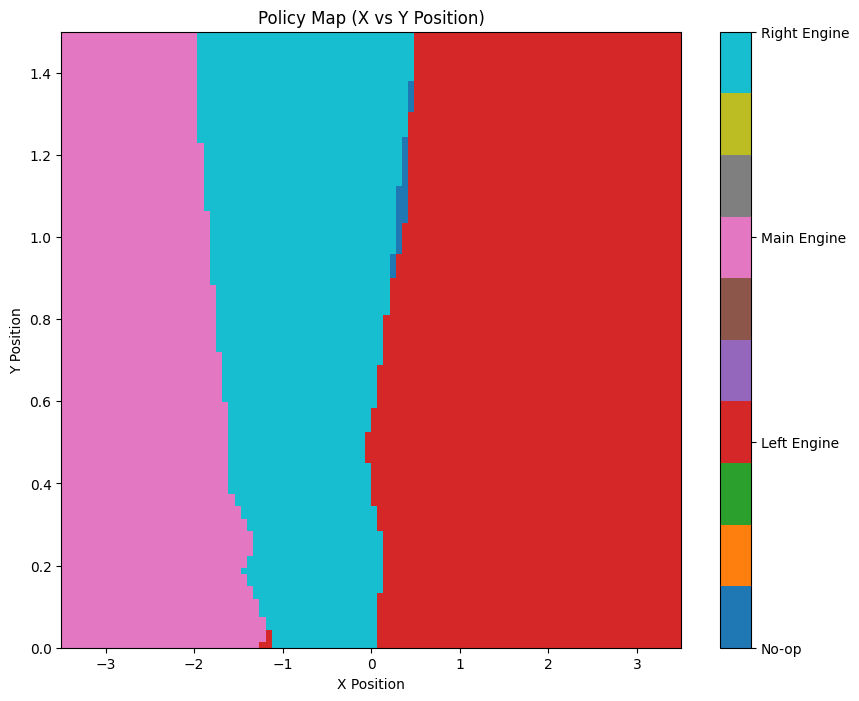

In [ ]:
for trainer in trainers:
    visualize(trainer.agent_network)